## Временные ряды: общая теория. Приведение шести рядов к стационарному виду

Шесть рядов из папки `Series`: помесячные продажи компании X, вооруженные ограбления в Бостоне,
пассажиры международных авиалиний, средняя месячная температура воздуха, недельное закрытие индекса
Доу-Джонса и ежедневные рождения девочек в Калифорнии. Ряды разной длины (от 77 до 365 точек),
разного шага (день, неделя, месяц) и разной природы - от климата до биржи.

Стационарность проверяется четырьмя способами сразу, как и советовали на занятии: взгляд на график,
метод интервалов, коррелограмма и расширенный тест Дики-Фуллера. Каждый из них по отдельности
обманывает, и дальше будет видно, где именно

### Задача 1. Шесть рядов и первый взгляд

Прежде чем что-то преобразовывать, надо увидеть, с чем имеем дело: сколько точек, какой шаг,
нет ли пропусков в календаре. Пропуск даты для временного ряда опаснее пропуска значения:
разность соседних точек молча посчитается через дыру и окажется не тем, чем кажется.

Ряды загружаются в общий словарь, дальше все шаги идут по нему

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style('whitegrid')


def месячный(файл, значение):
    df = pd.read_csv(файл)
    ряд = df[значение].astype(float)
    ряд.index = pd.PeriodIndex(df.iloc[:, 0], freq='M').to_timestamp()
    return ряд


def дневной(файл, значение):
    df = pd.read_csv(файл)
    ряд = df[значение].astype(float)
    ряд.index = pd.to_datetime(df.iloc[:, 0])
    return ряд


def недельный(файл, значение):
    df = pd.read_csv(файл)
    ряд = df[значение].astype(float)
    # неделя записана по ISO как 1971-W27, без дня такую строку в дату не превратить:
    # приписываем понедельник этой недели
    ряд.index = pd.to_datetime(df.iloc[:, 0] + '-1', format='%G-W%V-%u')
    return ряд


ряды = {
    'Продажи компании X': месячный('monthly-sales-of-company-x-jan-6.csv', 'Count'),
    'Ограбления в Бостоне': месячный('monthly-boston-armed-robberies-j.csv', 'Count'),
    'Пассажиры авиалиний': месячный('international-airline-passengers.csv', 'Count'),
    'Температура воздуха': месячный('mean-monthly-air-temperature-deg.csv', 'Deg'),
    'Индекс Доу-Джонса': недельный('weekly-closings-of-the-dowjones-.csv', 'Close'),
    'Рождения девочек': дневной('daily-total-female-births-in-cal.csv', 'Count'),
}

# шаг у каждого ряда свой, и по разнице дат его не восстановить: в месяцах от 28 до 31 дня.
# поэтому шаг задается явно, а календарь собирается заново и сверяется с фактическим
шаги = {'Продажи компании X': 'MS', 'Ограбления в Бостоне': 'MS', 'Пассажиры авиалиний': 'MS',
        'Температура воздуха': 'MS', 'Индекс Доу-Джонса': 'W-MON', 'Рождения девочек': 'D'}

опись = []
for имя, ряд in ряды.items():
    полный = pd.date_range(ряд.index[0], ряд.index[-1], freq=шаги[имя])
    опись.append({'ряд': имя, 'точек': len(ряд), 'дыр в календаре': len(set(полный) - set(ряд.index)),
                  'пропусков значений': int(ряд.isna().sum()),
                  'начало': ряд.index[0].date(), 'конец': ряд.index[-1].date(),
                  'минимум': ряд.min(), 'максимум': ряд.max(), 'среднее': round(ряд.mean(), 1)})

print(pd.DataFrame(опись).to_string(index=False))

                 ряд  точек  дыр в календаре  пропусков значений     начало      конец  минимум  максимум  среднее
  Продажи компании X     77                0                   0 1965-01-01 1971-05-01    36.00    895.00    298.4
Ограбления в Бостоне    118                0                   0 1966-01-01 1975-10-01    29.00    500.00    196.3
 Пассажиры авиалиний    144                0                   0 1949-01-01 1960-12-01   104.00    622.00    280.3
 Температура воздуха    240                0                   0 1920-01-01 1939-12-01    31.30     66.50     49.0
   Индекс Доу-Джонса    162                0                   0 1971-07-05 1974-08-05   752.58   1047.49    907.5
    Рождения девочек    365                0                   0 1959-01-01 1959-12-31    23.00     73.00     42.0


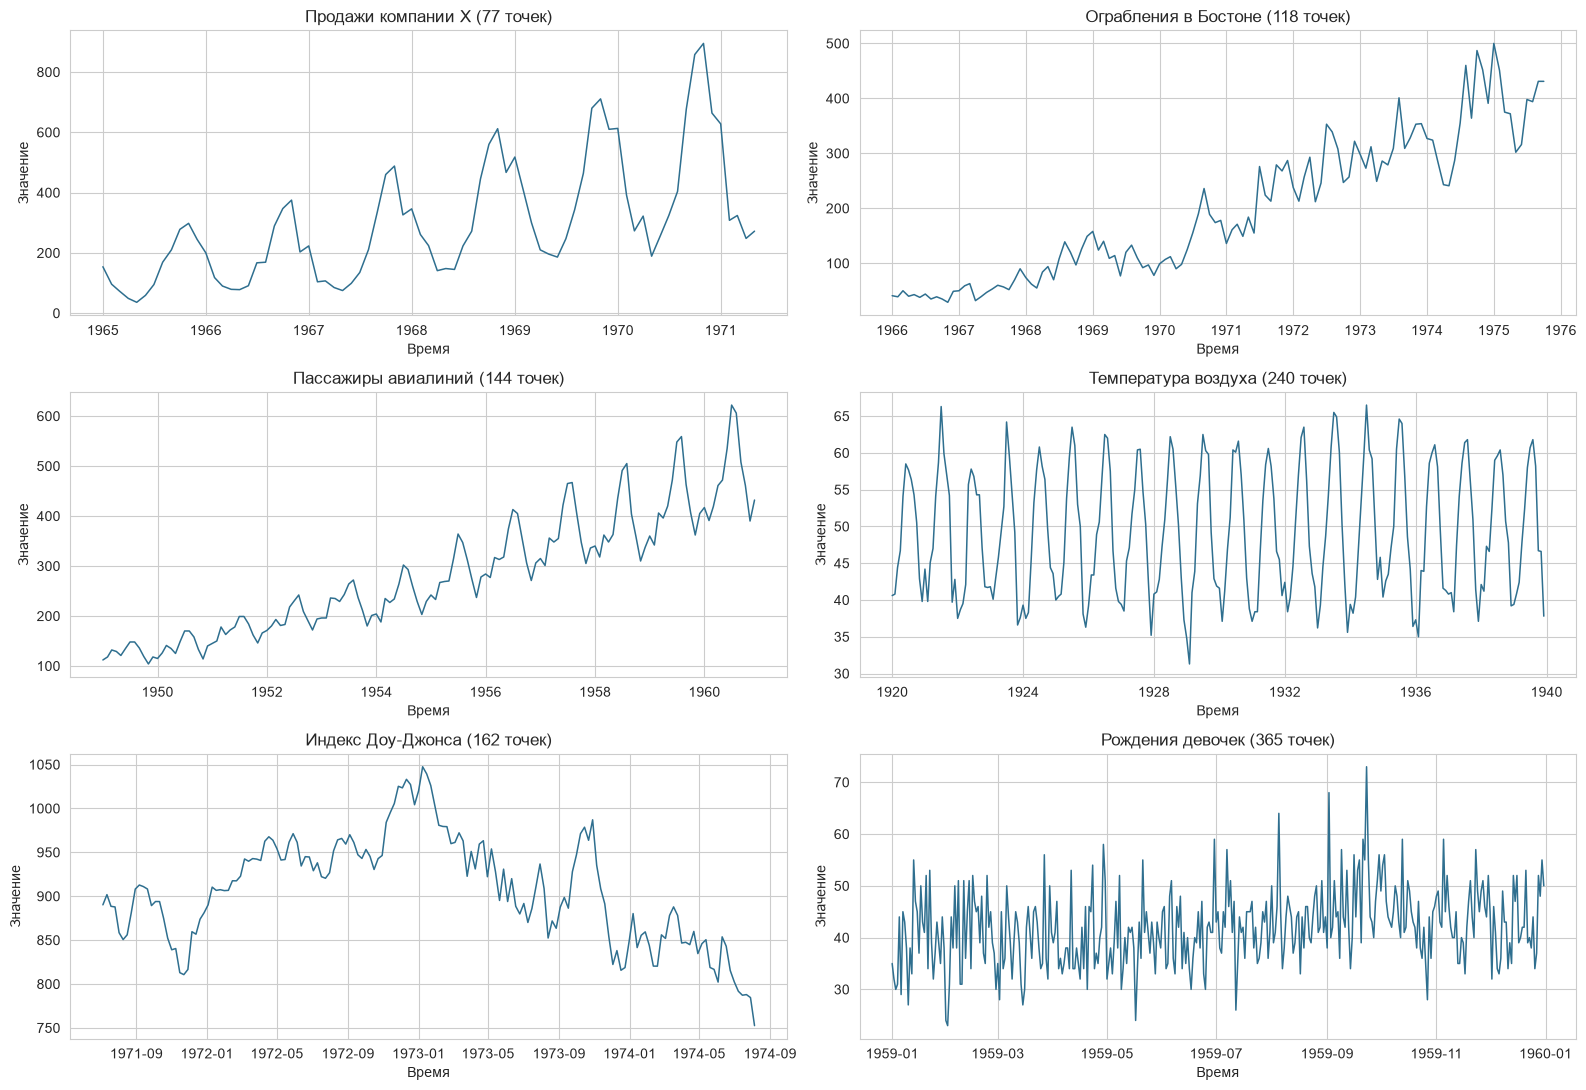

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(16, 11))
for ось, (имя, ряд) in zip(axes.flatten(), ряды.items()):
    ось.plot(ряд.index, ряд.values, color='#2f6f8f', linewidth=1.1)
    ось.set_title(f'{имя} ({len(ряд)} точек)')
    ось.set_xlabel('Время')
    ось.set_ylabel('Значение')
plt.tight_layout()
plt.show()

**Вывод по Задаче 1:**

Все шесть рядов целые: календарь без дыр, пропущенных значений нет. Длины от **77 точек**
у продаж компании X до **365** у рождений, размах значений от четырехкратного (температура,
31.3-66.5) до двадцатипятикратного (продажи, 36-895).

По виду графиков ряды делятся на три группы, и группа определяет, что с рядом придется делать.

*   **Растущие с расширяющимся размахом.** Продажи, ограбления и пассажиры авиалиний растут
    в несколько раз, и колебания вокруг уровня растут вместе с ним. У пассажиров это видно лучше
    всего: к концу ряда летние пики выше, но и провалы между ними глубже - размах годовой волны
    тянется за уровнем потока.
*   **Колеблющиеся без роста.** Температура воздуха: годовая волна одинаковой высоты двадцать лет
    подряд, среднее не сдвигается.
*   **Блуждающие.** Индекс Доу-Джонса идет вверх до начала 1973 года и падает дальше. Ни волны,
    ни постоянного наклона: уровень уходит, куда его уводят события.

Рождения девочек стоят особняком: на глаз это шум вокруг сорока двух рождений в день,
без видимого тренда и без видимой волны

### Задача 2. Чем проверяем стационарность

Тест Дики-Фуллера внутри строит авторегрессию, и число ее лагов он выбирает сам по информационному
критерию. Выбор не бесплатный: каждый лишний лаг съедает наблюдения, а самый короткий ряд здесь -
77 точек. Прежде чем доверять тесту на реальных данных, посмотрим, как он ведет себя на рядах,
про которые заранее известно, стационарны они или нет.

Возьмем два генератора. Первый дает ряд из скользящих средних с лагами 1 и 12 - он стационарен
по построению, но у него богатая короткая память, похожая на то, что остается после сезонного
дифференцирования. Второй дает случайное блуждание, оно нестационарно по построению. На первом
считаем, как часто тест верно говорит «стационарен», на втором - как часто он говорит то же самое
ошибочно. Сравним два способа выбирать число лагов, AIC и BIC

In [3]:
rng = np.random.default_rng(42)


def сезонный_ma(n):
    """стационарный по построению ряд: белый шум, размазанный по лагам 1 и 12"""
    e = rng.normal(size=n + 60)
    x = np.zeros(n + 60)
    for i in range(13, n + 60):
        x[i] = e[i] + 0.6 * e[i - 1] + 0.6 * e[i - 12] + 0.36 * e[i - 13]
    return x[60:]   # первые 60 точек выбрасываем, чтобы забыть про нулевой старт


def блуждание(n):
    """нестационарный по построению ряд: накопленная сумма шума"""
    return np.cumsum(rng.normal(size=n + 60))[60:]


испытаний = 300
калибровка = []
for генератор, подпись in [(сезонный_ma, 'сезонный MA (стационарен)'),
                           (блуждание, 'случайное блуждание (нестационарно)')]:
    for n in [65, 132, 228]:
        строка = {'ряд': подпись, 'длина': n}
        for критерий in ['AIC', 'BIC']:
            отвергнуто, лаги = 0, []
            for _ in range(испытаний):
                итог = adfuller(генератор(n), autolag=критерий)
                отвергнуто += итог[1] < 0.05
                лаги.append(итог[2])
            строка[f'{критерий}: доля ответов «стационарен»'] = round(отвергнуто / испытаний, 3)
            строка[f'{критерий}: средний лаг'] = round(np.mean(лаги), 1)
        калибровка.append(строка)

print(pd.DataFrame(калибровка).to_string(index=False))

                                ряд  длина  AIC: доля ответов «стационарен»  AIC: средний лаг  BIC: доля ответов «стационарен»  BIC: средний лаг
          сезонный MA (стационарен)     65                            0.603               5.8                            0.990               0.8
          сезонный MA (стационарен)    132                            0.167              11.3                            0.890               2.3
          сезонный MA (стационарен)    228                            0.370              13.0                            0.700               6.2
случайное блуждание (нестационарно)     65                            0.070               0.9                            0.030               0.1
случайное блуждание (нестационарно)    132                            0.053               0.9                            0.070               0.0
случайное блуждание (нестационарно)    228                            0.067               0.8                            0.073    

In [4]:
def проверка(x, название, сезон=12):
    """строка сводки по ряду: тест Дики-Фуллера, автокорреляции, разброс по четырем интервалам"""
    x = pd.Series(x).dropna()
    стат, p, лаг = adfuller(x, autolag='BIC')[:3]
    а = acf(x, nlags=max(24, сезон))
    порог = 2 / np.sqrt(len(x))   # обычная граница значимости автокорреляции
    значимые = [i for i in range(1, 25) if abs(а[i]) > порог]
    куски = np.array_split(x.values, 4)
    return {'преобразование': название, 'точек': len(x), 'лаг теста': лаг,
            'p-value': round(p, 4), 'разброс': round(x.std(), 4),
            'ACF(1)': round(а[1], 3), f'ACF({сезон})': round(а[сезон], 3),
            'значимых лагов из 24': len(значимые),
            'разброс по интервалам': ' '.join(f'{к.std(ddof=1):.3g}' for к in куски)}


def интервалы(x):
    """метод интервалов: у стационарного ряда среднее и разброс не зависят от куска"""
    куски = np.array_split(pd.Series(x).dropna().values, 4)
    return pd.DataFrame({'интервал': [1, 2, 3, 4],
                         'среднее': [round(к.mean(), 4) for к in куски],
                         'разброс': [round(к.std(ddof=1), 4) for к in куски]})


def портрет(варианты, лагов=24):
    """сам ряд, коррелограмма и частичная коррелограмма - визуальная проверка из занятия"""
    fig, axes = plt.subplots(len(варианты), 3, figsize=(16, 3.7 * len(варианты)))
    axes = np.atleast_2d(axes)
    for строка, (название, x) in enumerate(варианты):
        x = pd.Series(x).dropna()
        л = min(лагов, len(x) // 2 - 1)
        axes[строка, 0].plot(x.index, x.values, color='#2f6f8f', linewidth=1.1)
        axes[строка, 0].set_title(название)
        axes[строка, 0].set_xlabel('Время')
        axes[строка, 0].set_ylabel('Значение')
        plot_acf(x.values, lags=л, ax=axes[строка, 1], title='Коррелограмма ACF')
        axes[строка, 1].set_xlabel('Лаг')
        axes[строка, 1].set_ylabel('Автокорреляция')
        plot_pacf(x.values, lags=л, ax=axes[строка, 2], title='Частичная коррелограмма PACF',
                  method='ywm')
        axes[строка, 2].set_xlabel('Лаг')
        axes[строка, 2].set_ylabel('Частичная автокорреляция')
    plt.tight_layout()
    plt.show()

**Вывод по Задаче 2:**

Тест Дики-Фуллера сам по себе не гарантия. На ряде, стационарном **по построению**, версия
с выбором лагов по AIC отвечает верно только в **60.3%** случаев при 65 точках и в **16.7%**
при 132. Версия с BIC на тех же данных дает **99.0%** и **89.0%**.

Разница целиком объясняется числом лагов: AIC берет **5.8** лага в среднем на коротком ряде
и **11.3** на среднем, BIC - **0.8** и **2.3**. Каждый лаг это оцениваемый коэффициент и одно
потерянное наблюдение, и при 132 точках AIC съедает почти десятую часть ряда.

**Осторожность BIC не куплена ценой ложных тревог.** На случайном блуждании, нестационарном
по построению, оба критерия ошибаются примерно с заявленной частотой: AIC в 5.3-7.0% случаев,
BIC в 3.0-7.3%. То есть BIC не стал чаще принимать нестационарный ряд за стационарный, он просто
перестал упускать стационарный.

Есть и то, чего таблица не объясняет: у обоих критериев доля верных ответов на стационарном ряде
падает с ростом длины ряда, хотя данных становится больше. В той же таблице видно, что вместе
с длиной растет и выбранный лаг (у BIC с 0.8 до 6.2), но из наблюдения за двумя столбцами связь
не следует. Проверить ее можно повтором того же опыта с жестко заданным числом лагов: если
при фиксированном лаге доля верных ответов с длиной ряда перестанет падать, дело в лагах.

Дальше везде используется BIC, а вывод о стационарности делается по совокупности: тест,
коррелограмма, метод интервалов и график

### Задача 3. Продажи компании X

Ряд короткий - 77 месяцев, с января 1965 по май 1971 года. На графике видно и рост, и годовую волну,
причем размах волны растет вместе с уровнем продаж: это признак того, что сезонность здесь
мультипликативная, то есть выражена в процентах от уровня, а не в штуках.

Проверим это методом интервалов: если разброс внутри куска растет вместе со средним, ряд надо сначала
логарифмировать - логарифм превращает постоянный процент в постоянную добавку. Дальше сравним
два способа убрать оставшиеся тренд и сезонность: дифференцирование и вычитание оцененных компонент

In [5]:
ряд = ряды['Продажи компании X']
print('связь уровня и разброса на исходном ряде:')
print(интервалы(ряд).to_string(index=False))

лог = np.log(ряд)
print('\nтот же ряд после логарифмирования:')
print(интервалы(лог).to_string(index=False))
отношение = lambda x: интервалы(x).разброс.max() / интервалы(x).разброс.min()
print(f'отношение наибольшего разброса к наименьшему: исходный ряд {отношение(ряд):.2f}, '
      f'логарифм {отношение(лог):.2f}')

связь уровня и разброса на исходном ряде:
 интервал  среднее  разброс
        1 137.7000  77.1506
        2 247.0000 126.9825
        3 345.3158 169.9951
        4 472.0526 222.0504

тот же ряд после логарифмирования:
 интервал  среднее  разброс
        1   4.7678   0.5913
        2   5.3599   0.5924
        3   5.7232   0.5152
        4   6.0509   0.4760
отношение наибольшего разброса к наименьшему: исходный ряд 2.88, логарифм 1.24


In [6]:
# линейный тренд оценивается по логарифму: в логарифме постоянный процент роста дает прямую
t = np.arange(len(лог))
рег = stats.linregress(t, лог.values)
тренд = pd.Series(рег.intercept + рег.slope * t, index=лог.index)
без_тренда = лог - тренд
# профиль месяца - средний уровень каждого календарного месяца после снятия тренда
профиль = без_тренда.groupby(без_тренда.index.month).transform('mean')

print(f'рост в логарифме: {рег.slope:.5f} за месяц, то есть {(np.exp(рег.slope) - 1) * 100:.1f}% '
      f'в месяц, p-value наклона {рег.pvalue:.2e}, доля объясненной дисперсии {рег.rvalue ** 2:.2f}')
print('профиль месяцев (отклонение логарифма от тренда):')
print({м: round(з, 2) for м, з in без_тренда.groupby(без_тренда.index.month).mean().items()})

продажи_итог = без_тренда - профиль
кандидаты = pd.DataFrame([
    проверка(ряд, 'исходный ряд'),
    проверка(лог, 'логарифм'),
    проверка(лог.diff(12), 'логарифм + сезонная разность'),
    проверка(лог.diff(12).diff(), 'логарифм + сезонная разность + разность'),
    проверка(продажи_итог, 'логарифм - тренд - профиль месяца'),
])
print('\n' + кандидаты.to_string(index=False))

рост в логарифме: 0.02187 за месяц, то есть 2.2% в месяц, p-value наклона 1.21e-11, доля объясненной дисперсии 0.46
профиль месяцев (отклонение логарифма от тренда):
{1: 0.39, 2: -0.12, 3: -0.33, 4: -0.59, 5: -0.74, 6: -0.58, 7: -0.21, 8: 0.07, 9: 0.46, 10: 0.71, 11: 0.76, 12: 0.41}

                         преобразование  точек  лаг теста  p-value  разброс  ACF(1)  ACF(12)  значимых лагов из 24   разброс по интервалам
                           исходный ряд     77         12   0.9889 198.4306   0.871    0.676                    11        77.2 127 170 222
                               логарифм     77          8   0.8052   0.7212   0.895    0.674                    13 0.591 0.592 0.515 0.476
           логарифм + сезонная разность     65          1   0.1549   0.2333   0.450   -0.257                     4 0.248 0.273 0.111 0.215
логарифм + сезонная разность + разность     64          0   0.0000   0.2461  -0.583   -0.356                     5 0.277 0.241 0.115 0.325
      логарифм - тре

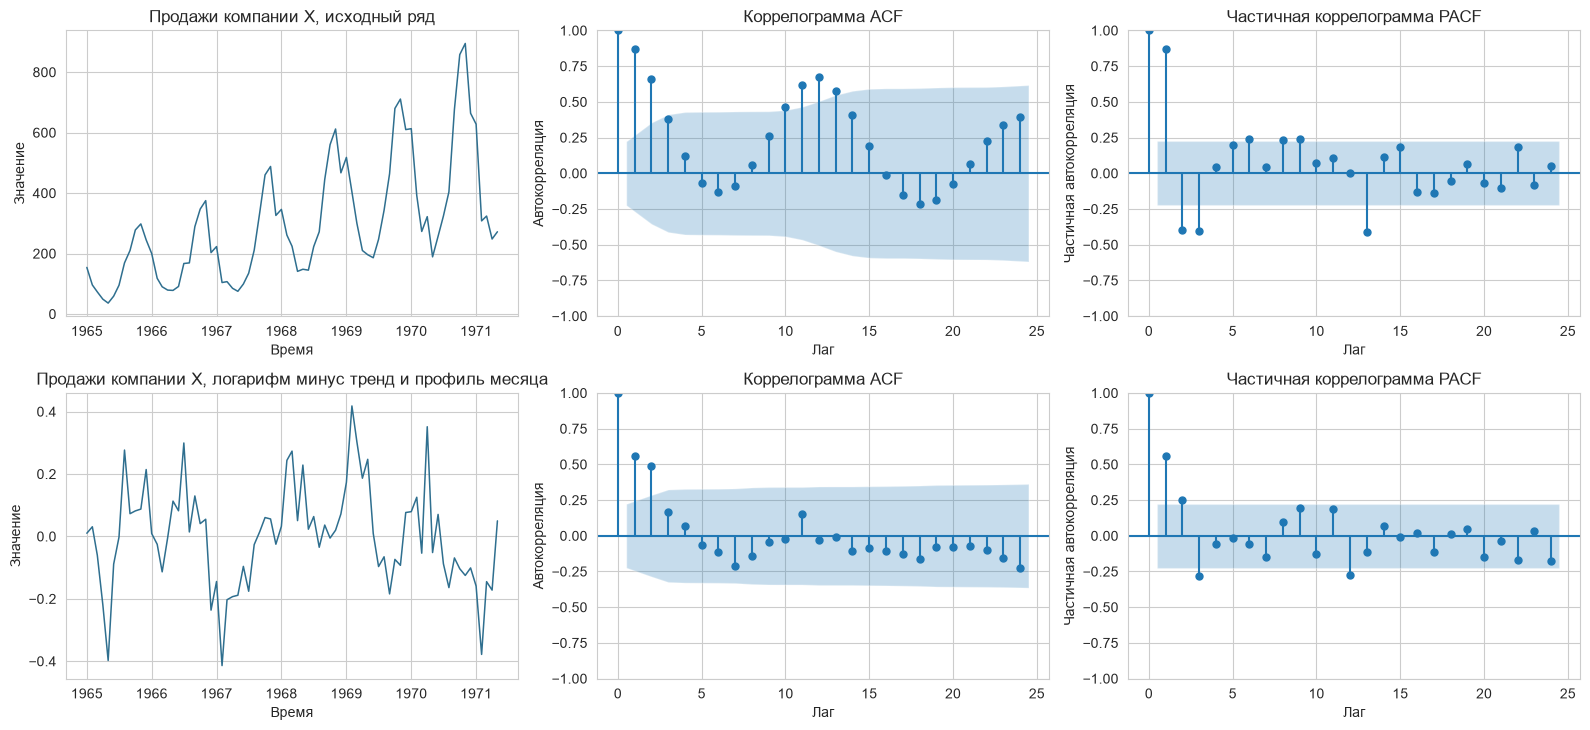

 интервал  среднее  разброс
        1   0.0190   0.1584
        2  -0.0420   0.1722
        3   0.0721   0.1517
        4  -0.0501   0.1528


In [7]:
портрет([('Продажи компании X, исходный ряд', ряд),
         ('Продажи компании X, логарифм минус тренд и профиль месяца', продажи_итог)])
print(интервалы(продажи_итог).to_string(index=False))

**Вывод по Задаче 3:**

**Мультипликативность подтвердилась замером.** На исходном ряде среднее по интервалам растет
137.7 -> 472.1, и разброс идет за ним: 77.2 -> 222.1. Отношение наибольшего разброса
к наименьшему **2.88**. После логарифмирования разбросы становятся 0.591, 0.592, 0.515, 0.476,
отношение **1.24** - связь уровня и размаха пропала.

В логарифме ряд растет на **2.2% в месяц** (наклон 0.0219, p-value 1.2e-11), но прямая объясняет
только **46%** его разброса. Остальное - сезонная волна, и она огромна: профиль месяцев тянется
от **-0.74 в мае до +0.76 в ноябре**, то есть ноябрьские продажи примерно **в 4.5 раза** выше
майских. Что за товар так продается, из данных не узнать: в файле только «компания X», ни отрасли,
ни единиц измерения. Любая версия про предновогодний спрос здесь останется версией.

**Из трех способов убрать тренд и сезонность выиграло вычитание оцененных компонент.** Сезонная
разность одна не справилась (p-value **0.1549**). Добавленная к ней обычная разность довела тест
до 0.0000, но испортила остальное: **ACF(1) упал до -0.583** при том, что до разности он был
положительным, а разброс вырос с 0.2333 до 0.2461. Отрицательная автокорреляция первого лага
и выросший разброс - это то, что получается, когда ряд продифференцировали лишний раз.

Вычитание тренда и профиля месяца дало p-value **0.0026** при самом маленьком разбросе **0.1635**,
двух значимых лагах из 24 против пяти и ровных интервалах (0.158, 0.172, 0.152, 0.153).

**ACF(1) остаточного ряда 0.561** - стационарность не означает независимости соседних точек.
Хороший месяц тянет за собой следующий, память живет примерно два месяца, и это как раз то,
что осталось для моделирования после снятия тренда и сезона

### Задача 4. Вооруженные ограбления в Бостоне

118 месяцев с января 1966 по октябрь 1975 года. Ряд вырос с полусотни ограблений в месяц до
четырех с половиной сотен, и разброс вырос вместе с уровнем - значит, снова начинаем с логарифма.

А вот природа роста здесь другая, чем у продаж. Продажи росли ровным процентом, и прямая в логарифме
описывала их неплохо. Здесь рост то ускоряется, то останавливается, и подгонять прямую под такое
незачем: от накопительного, блуждающего тренда избавляются дифференцированием. Проверим,
нужна ли вдобавок сезонная разность

In [8]:
ряд = ряды['Ограбления в Бостоне']
лог = np.log(ряд)
t = np.arange(len(лог))
рег = stats.linregress(t, лог.values)
без_тренда = лог - (рег.intercept + рег.slope * t)
профиль = без_тренда.groupby(без_тренда.index.month).transform('mean')

print('исходный ряд по интервалам:')
print(интервалы(ряд).to_string(index=False))
print('\nлогарифм по интервалам:')
print(интервалы(лог).to_string(index=False))

# ровный ли рост: если да, прямая в логарифме подойдет, как подошла продажам
по_годам = ряд.groupby(ряд.index.year).mean()
print('\nсреднее число ограблений в месяц по годам:')
print({г: round(з, 1) for г, з in по_годам.items()})
print('прирост год к году, процентов:')
print({г: round(з, 1) for г, з in (по_годам.pct_change() * 100).dropna().items()})

ограбления_итог = лог.diff()
кандидаты = pd.DataFrame([
    проверка(ряд, 'исходный ряд'),
    проверка(ряд.diff(), 'разность без логарифма'),
    проверка(ограбления_итог, 'логарифм + разность'),
    проверка(лог.diff().diff(12), 'логарифм + разность + сезонная разность'),
    проверка(без_тренда - профиль, 'логарифм - тренд - профиль месяца'),
])
print('\n' + кандидаты.to_string(index=False))

исходный ряд по интервалам:
 интервал  среднее  разброс
        1  53.1000  16.9774
        2 128.1333  37.0663
        3 248.4828  58.5263
        4 362.7241  70.0392

логарифм по интервалам:
 интервал  среднее  разброс
        1   3.9258   0.3064
        2   4.8161   0.2720
        3   5.4854   0.2572
        4   5.8754   0.1958

среднее число ограблений в месяц по годам:
{1966: 40.2, 1967: 56.0, 1968: 98.2, 1969: 112.7, 1970: 146.1, 1971: 208.6, 1972: 273.8, 1973: 312.6, 1974: 351.3, 1975: 397.0}
прирост год к году, процентов:
{1967: 39.4, 1968: 75.3, 1969: 14.8, 1970: 29.7, 1971: 42.8, 1972: 31.2, 1973: 14.2, 1974: 12.4, 1975: 13.0}

                         преобразование  точек  лаг теста  p-value  разброс  ACF(1)  ACF(12)  значимых лагов из 24   разброс по интервалам
                           исходный ряд    118          1   0.7499 128.0436   0.928    0.668                    24         17 37.1 58.5 70
                 разность без логарифма    117          1   0.0000  41.2145 

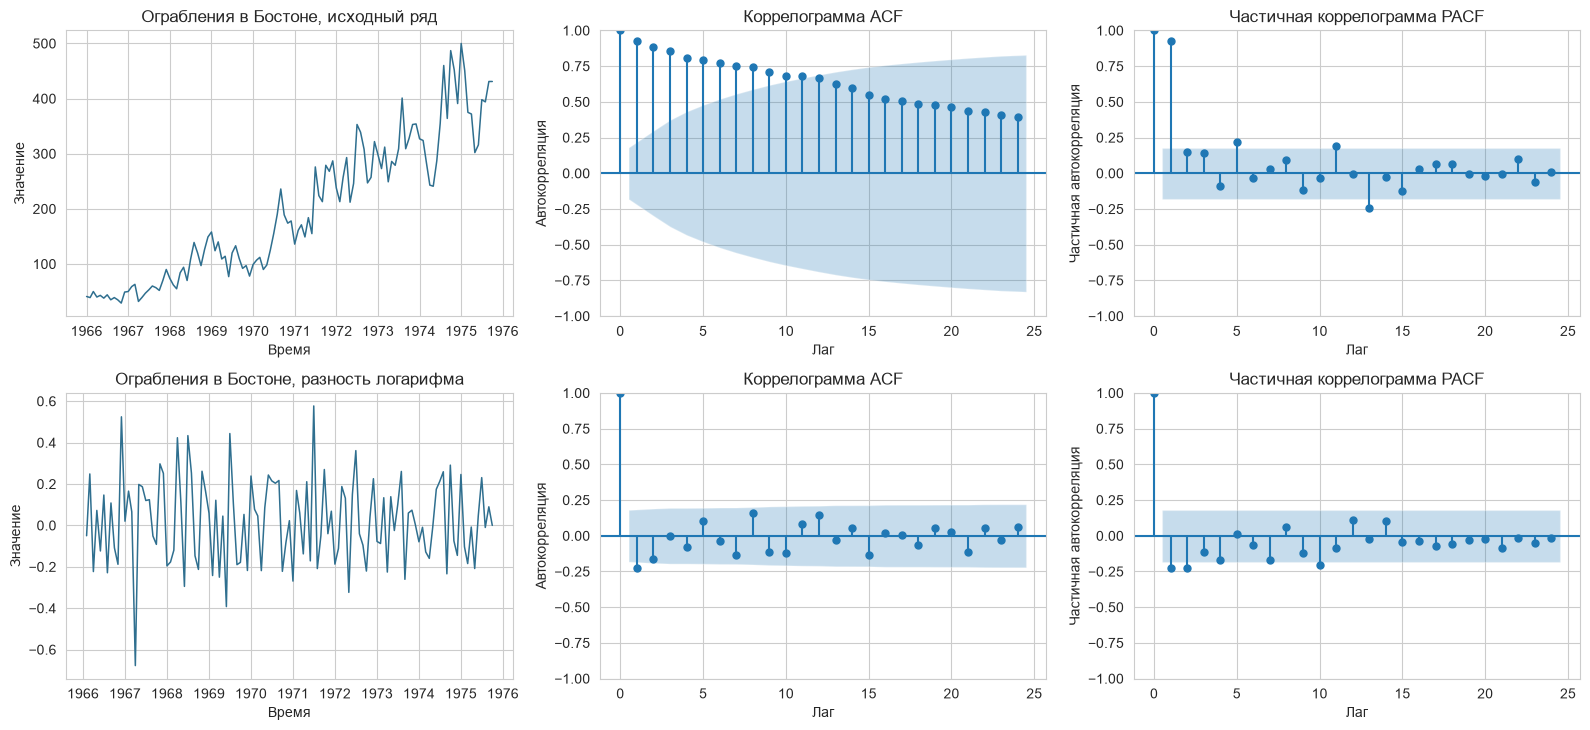

 интервал  среднее  разброс
        1   0.0323   0.2505
        2   0.0172   0.2079
        3   0.0164   0.2086
        4   0.0141   0.1603


In [9]:
портрет([('Ограбления в Бостоне, исходный ряд', ряд),
         ('Ограбления в Бостоне, разность логарифма', ограбления_итог)])
print(интервалы(ограбления_итог).to_string(index=False))

**Вывод по Задаче 4:**

Логарифм здесь нужен по той же причине, что и в продажах: среднее по интервалам растет
53.1 -> 362.7, разброс 17.0 -> 70.0, а в логарифме разбросы почти выравниваются
(0.306, 0.272, 0.257, 0.196).

**А дальше два ряда расходятся, и таблица показывает это прямо.** У продаж выиграло вычитание
прямой и профиля, здесь тот же прием дает **ACF(1) 0.678 и восемь значимых лагов из 24**:
прямая не описывает этот рост. И правда, ровным он не был: **+75% за 1968 год**, следом +15%,
потом снова +43% в 1971-м, а с 1973-го рост держится на 12-15% в год. Такой уровень не колеблется
вокруг заданной линии, он сдвигается и остается на новом месте. От такого тренда избавляются
разностью.

**Разность логарифма и есть ответ:** p-value **0.0000**, разброс 0.2071, и **один значимый лаг
из двадцати четырех**. Это самый чистый результат из шести рядов.

**Сезонная разность не нужна и вредна.** У разности логарифма ACF(12) равен **0.144** при границе
значимости 0.185 - годового следа не осталось. Если сезонную разность все же добавить, ACF(12)
уходит в **-0.426**, значимых лагов становится пять, а разброс растет с 0.207 до 0.273.

У преобразованного ряда есть прямой смысл: разность логарифма это **месячный темп прироста**.
Средние по интервалам 3.2%, 1.7%, 1.6%, 1.4% - рост держится все десять лет, а разница между
интервалами тонет в разбросе: при 0.207 на 29 наблюдениях случайный разброс среднего около
четырех процентных пунктов, то есть больше самих различий

### Задача 5. Пассажиры международных авиалиний

Самый известный ряд из шести: 144 месяца с 1949 по 1960 год, учебный пример почти во всех курсах
по временным рядам. Пассажиропоток растет втрое за двенадцать лет, каждое лето дает пик,
и высота летнего пика растет вместе с потоком.

Здесь есть и тренд, и сезонность, и оба выглядят накопительными: уровень каждого следующего года
отталкивается от предыдущего, а не колеблется вокруг общей прямой. Проверим связку из трех операций -
логарифм, сезонная разность и обычная разность, - сравнив ее с более короткими вариантами

In [10]:
ряд = ряды['Пассажиры авиалиний']
лог = np.log(ряд)
t = np.arange(len(лог))
рег = stats.linregress(t, лог.values)
без_тренда = лог - (рег.intercept + рег.slope * t)
профиль = без_тренда.groupby(без_тренда.index.month).transform('mean')

print('исходный ряд по интервалам:')
print(интервалы(ряд).to_string(index=False))
print('\nлогарифм по интервалам:')
print(интервалы(лог).to_string(index=False))

авиа_итог = лог.diff(12).diff()
кандидаты = pd.DataFrame([
    проверка(ряд, 'исходный ряд'),
    проверка(лог, 'логарифм'),
    проверка(лог.diff(), 'логарифм + разность'),
    проверка(лог.diff(12), 'логарифм + сезонная разность'),
    проверка(авиа_итог, 'логарифм + сезонная разность + разность'),
    проверка(ряд.diff(12).diff(), 'сезонная разность + разность без логарифма'),
    проверка(без_тренда - профиль, 'логарифм - тренд - профиль месяца'),
])
print('\n' + кандидаты.to_string(index=False))

исходный ряд по интервалам:
 интервал  среднее  разброс
        1 145.5000  24.9439
        2 220.3056  33.4116
        3 326.8889  59.6148
        4 428.5000  79.3292

логарифм по интервалам:
 интервал  среднее  разброс
        1   4.9661   0.1694
        2   5.3842   0.1486
        3   5.7740   0.1779
        4   6.0444   0.1791

                            преобразование  точек  лаг теста  p-value  разброс  ACF(1)  ACF(12)  значимых лагов из 24       разброс по интервалам
                              исходный ряд    144         13   0.9919 119.9663   0.948    0.760                    24         24.9 33.4 59.6 79.3
                                  логарифм    144         13   0.4224   0.4415   0.954    0.762                    24     0.169 0.149 0.178 0.179
                       логарифм + разность    143         12   0.0302   0.1066   0.200    0.841                    10     0.104 0.103 0.108 0.116
              логарифм + сезонная разность    132          1   0.0131   0.0616   0

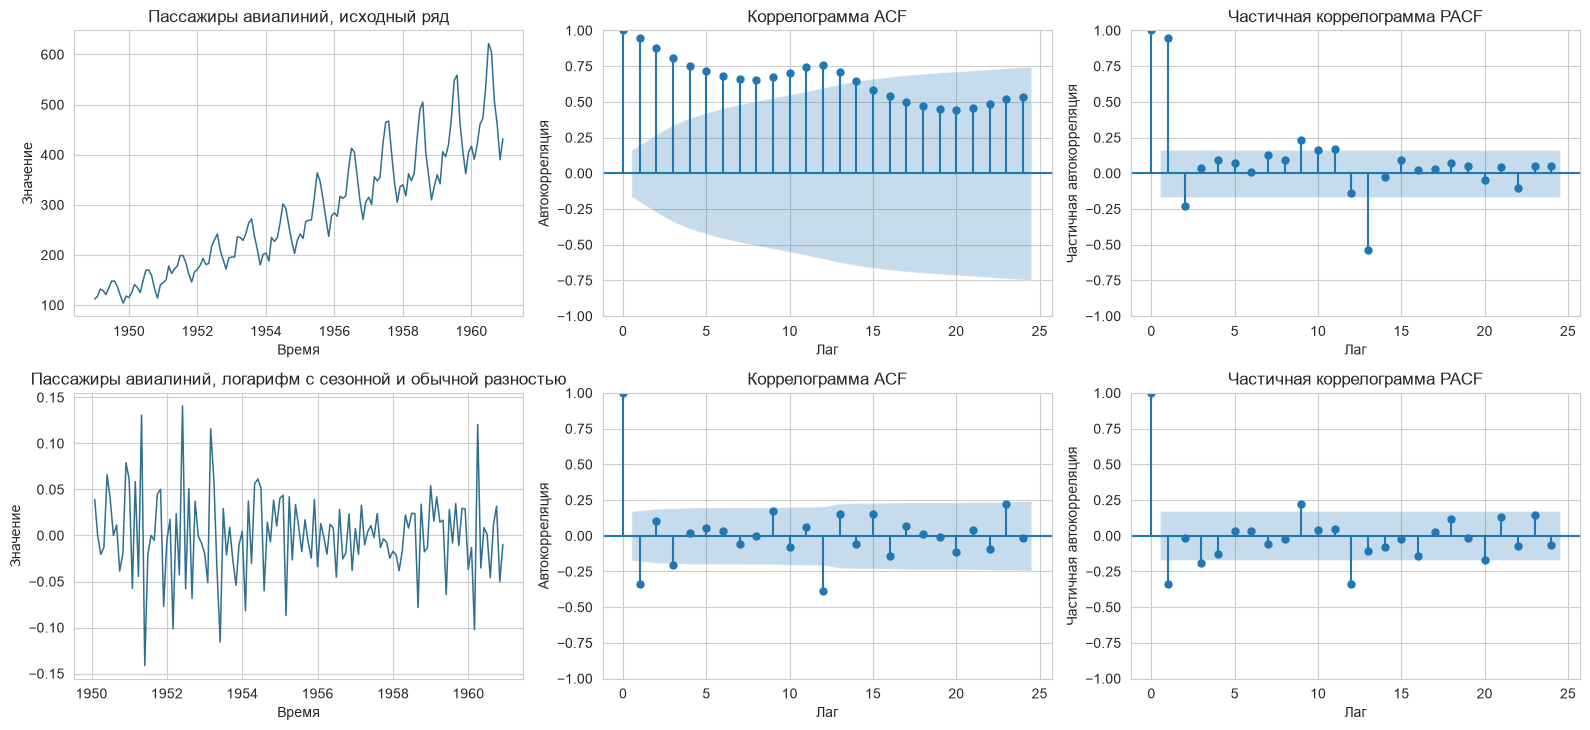

 интервал  среднее  разброс
        1   0.0042   0.0615
        2   0.0007   0.0496
        3  -0.0057   0.0218
        4   0.0020   0.0427


In [11]:
портрет([('Пассажиры авиалиний, исходный ряд', ряд),
         ('Пассажиры авиалиний, логарифм с сезонной и обычной разностью', авиа_итог)])
print(интервалы(авиа_итог).to_string(index=False))

**Вывод по Задаче 5:**

Логарифм оправдан замером: на исходном ряде разбросы по интервалам 24.9, 33.4, 59.6, 79.3
(отношение **3.18**), в логарифме - 0.169, 0.149, 0.178, 0.179 (отношение **1.20**). Летний пик
растет не на постоянное число пассажиров, а на постоянную долю.

**Каждая из двух разностей убирает ровно свое, и по одной ни одна не справляется.** После обычной
разности логарифма ACF(12) остается **0.841** - тренд снят, годовая волна нетронута. После одной
сезонной разности ACF(1) равен **0.714** - волна снята, тренд остался. Обе вместе дают p-value
**0.0000**, ACF(1) **-0.341** и самый маленький разброс из всех вариантов, **0.0458**.

**Вычитание прямой и профиля здесь проваливается** (ACF(1) 0.779, четырнадцать значимых лагов
из 24), и это обратная сторона того, что вышло с продажами. Там сезонная волна повторялась
достаточно ровно, чтобы ее описал один профиль; здесь и уровень, и высота летнего пика
отталкиваются от прошлого года, а не от общей линии.

**Логарифм проверяется по направлению, а не по отношению разбросов.** У варианта без логарифма
отношение наибольшего разброса к наименьшему даже меньше (2.16 против 2.82), но разбросы там
идут 10.0, 11.1, 8.4, 18.2 - к концу ряда вдвое больше, чем в начале. У логарифмированного
варианта 0.0615, 0.0496, 0.0218, 0.0427 - без направления, третий интервал самый спокойный,
а последний не выделяется. Постоянство дисперсии нарушает именно рост, а не разброс сам по себе.

Смысл итогового ряда: **прирост к тому же месяцу прошлого года, взятый в процентах и очищенный
от общего прироста**. Иными словами, чем этот июль отличается от прошлого июля сверх того,
на сколько вырос весь поток

### Задача 6. Средняя месячная температура воздуха

240 месяцев подряд, с 1920 по 1939 год. Значения лежат между 31 и 66 - для градусов Цельсия это
невозможный размах, для Фаренгейта обычный: примерно от нуля до девятнадцати градусов Цельсия.

Ряд устроен принципиально иначе, чем предыдущие три. Никакого роста здесь быть не может: климат
за двадцать лет не сдвигается настолько, чтобы это было видно на глаз, а годовая волна задана
наклоном земной оси и повторяется из года в год почти одинаково. Такая сезонность
**детерминированная**: она не накапливается, а воспроизводится.

Разница между накопительной и детерминированной сезонностью не умозрительная, у нее есть проверяемое
следствие. Если сезонная волна повторяется точно, то сезонная разность вычитает из шума этого года
шум прошлого года: дисперсия остатка становится вдвое больше, а автокорреляция на сезонном лаге
падает примерно до минус 0.5. Посчитаем оба числа и сравним с вычитанием месячного профиля

In [12]:
ряд = ряды['Температура воздуха']
# профиль месяца: средняя температура каждого календарного месяца за все двадцать лет
профиль = ряд.groupby(ряд.index.month).transform('mean')
температура_итог = ряд - профиль

print('средняя температура по месяцам, градусы Фаренгейта:')
print({м: round(з, 1) for м, з in ряд.groupby(ряд.index.month).mean().items()})

кандидаты = pd.DataFrame([
    проверка(ряд, 'исходный ряд'),
    проверка(ряд.diff(12), 'сезонная разность'),
    проверка(температура_итог, 'вычитание профиля месяца'),
    проверка(температура_итог.diff(), 'вычитание профиля + разность'),
])
print('\n' + кандидаты.to_string(index=False))

сезонная = ряд.diff(12).dropna()
print(f'\nдисперсия: исходный ряд {ряд.var():.2f}, после сезонной разности {сезонная.var():.2f}, '
      f'после вычитания профиля {температура_итог.var():.2f}')
print(f'отношение дисперсий, сезонная разность к профилю: {сезонная.var() / температура_итог.var():.2f} '
      f'(ожидалось около 2)')
print(f'ACF(12): после сезонной разности {acf(сезонная, nlags=12)[12]:.3f} (ожидалось около -0.5), '
      f'после вычитания профиля {acf(температура_итог, nlags=12)[12]:.3f}')

средняя температура по месяцам, градусы Фаренгейта:
{1: 39.7, 2: 39.2, 3: 42.2, 4: 46.3, 5: 52.6, 6: 58.0, 7: 61.9, 8: 60.5, 9: 56.5, 10: 49.5, 11: 42.6, 12: 39.5}

              преобразование  точек  лаг теста  p-value  разброс  ACF(1)  ACF(12)  значимых лагов из 24 разброс по интервалам
                исходный ряд    240         12   0.0594   8.5697   0.808    0.884                    20   8.01 8.78 9.08 8.56
           сезонная разность    228         12   0.0000   3.4394   0.195   -0.626                     6   4.03 3.29 3.18 3.24
    вычитание профиля месяца    240          0   0.0000   2.2593   0.237   -0.137                     4        2.6 2.12 2.2 2
вычитание профиля + разность    239          5   0.0000   2.7945  -0.444   -0.207                     5    3.15 2.54 2.6 2.91

дисперсия: исходный ряд 73.44, после сезонной разности 11.83, после вычитания профиля 5.10
отношение дисперсий, сезонная разность к профилю: 2.32 (ожидалось около 2)
ACF(12): после сезонной разности -0.62

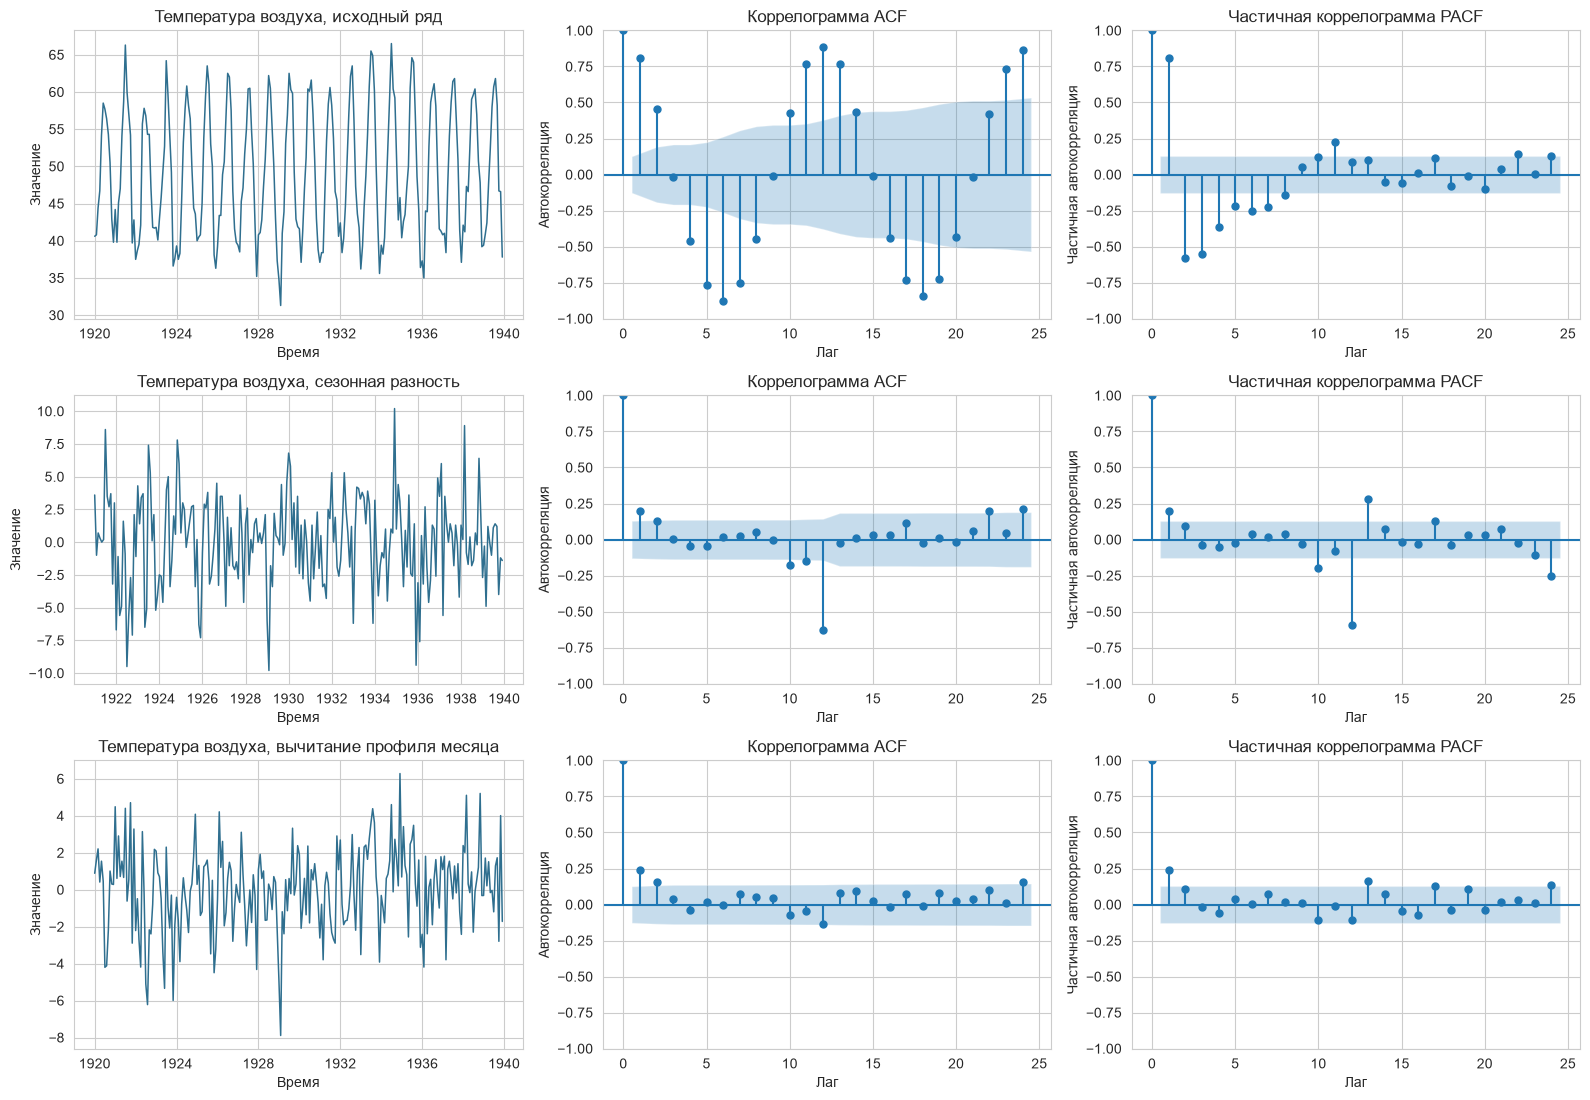

 интервал  среднее  разброс
        1  -0.3479   2.6039
        2  -0.3779   2.1248
        3   0.3154   2.1991
        4   0.4104   2.0011


In [13]:
портрет([('Температура воздуха, исходный ряд', ряд),
         ('Температура воздуха, сезонная разность', ряд.diff(12)),
         ('Температура воздуха, вычитание профиля месяца', температура_итог)])
print(интервалы(температура_итог).to_string(index=False))

**Вывод по Задаче 6:**

**Тест здесь не помощник, а коррелограмма отвечает сразу.** На исходном ряде p-value **0.0594** -
у самой границы, вывода не дает ни в одну сторону. При этом **ACF(12) равен 0.884**: температура
этого января почти повторяет температуру прошлого января, и никаких сомнений в сезонности нет.
Ровно ради таких случаев на занятии и советовали комбинировать методы.

**Предсказание про детерминированную сезонность сошлось с замером.** Если волна повторяется точно,
сезонная разность вычитает из шума этого года шум прошлого, и дисперсия должна вырасти примерно
вдвое, а ACF на сезонном лаге - упасть примерно до -0.5. Замер: дисперсия остатка после сезонной
разности **11.83** против **5.10** после вычитания профиля, отношение **2.32**; ACF(12) после
разности **-0.626**.

Отклонение от ровной двойки объясняется тем же замером. Остаток не белый шум: у него собственная
автокорреляция на сезонном лаге **-0.137**, и с ней ожидаемое отношение дисперсий равно
2 * (1 + 0.137) = **2.27** против замеренных 2.32.

**Поэтому сезонная разность здесь - неподходящий инструмент**, хотя формально она проходит тест
(p-value 0.0000). Она вносит в остаток лишний шум прошлого года. Вычитание профиля месяца дает
вдвое меньшую дисперсию, ACF(12) **-0.137** вместо -0.626 и ровные интервалы (2.60, 2.12, 2.20, 2.00).

У остатка есть прямой физический смысл: это **погодная аномалия**, насколько конкретный январь
теплее или холоднее среднего января за двадцать лет. Средние по интервалам сдвигаются
с -0.35 до +0.41, то есть вторая половина двадцатилетия примерно на **0.7 градуса Фаренгейта**
теплее первой. При разбросе 2.26 на шестидесяти точках это на грани различимого, и делать
из одного ряда климатический вывод нельзя

### Задача 7. Недельное закрытие индекса Доу-Джонса

162 недели с июля 1971 по август 1974 года. На этот отрезок приходится биржевой спад 1973-1974 годов:
индекс поднимается выше 1040 и опускается ниже 760.

У биржевой цены нет ни сезонности, ни тренда в обычном смысле: завтрашняя цена это сегодняшняя плюс
непредсказуемая новость. Такой ряд называют случайным блужданием, и дифференцирование для него -
не технический прием, а переход к тому, что имеет экономический смысл, к недельному изменению цены.

Проверим заодно, нужен ли логарифм. Логарифм помогает, когда разброс растет вместе с уровнем,
посмотрим, так ли это здесь

In [14]:
ряд = ряды['Индекс Доу-Джонса']
лог = np.log(ряд)
доу_итог = ряд.diff()

print('исходный ряд по интервалам:')
print(интервалы(ряд).to_string(index=False))

кандидаты = pd.DataFrame([
    проверка(ряд, 'исходный ряд', сезон=52),
    проверка(лог, 'логарифм', сезон=52),
    проверка(доу_итог, 'разность', сезон=52),
    проверка(лог.diff(), 'логарифм + разность', сезон=52),
])
print('\n' + кандидаты.to_string(index=False))
print('\nнедельные изменения по интервалам:')
print(интервалы(доу_итог).to_string(index=False))

# постоянна ли дисперсия: сравниваем разброс первой и второй половины изменений
разности = доу_итог.dropna()
первая, вторая = разности[:len(разности) // 2], разности[len(разности) // 2:]
лог_разности = лог.diff().dropna()
л1, л2 = лог_разности[:len(лог_разности) // 2], лог_разности[len(лог_разности) // 2:]
print(f'\nразброс недельных изменений: первая половина {первая.std():.2f}, вторая {вторая.std():.2f}, '
      f'критерий Левене p-value {stats.levene(первая, вторая).pvalue:.2e}')
print(f'то же для изменений логарифма: {л1.std():.4f} и {л2.std():.4f}, '
      f'p-value {stats.levene(л1, л2).pvalue:.2e}')

исходный ряд по интервалам:
 интервал  среднее  разброс
        1 890.3917  37.0899
        2 969.1688  36.1782
        3 929.4850  40.0851
        4 839.7788  35.9831

     преобразование  точек  лаг теста  p-value  разброс  ACF(1)  ACF(52)  значимых лагов из 24       разброс по интервалам
       исходный ряд    162          0   0.6225  60.5999   0.926   -0.266                    24           37.1 36.2 40.1 36
           логарифм    162          0   0.6691   0.0672   0.922   -0.252                    24  0.042 0.0369 0.0433 0.0428
           разность    161          0   0.0000  19.8531  -0.042    0.003                     3         14.6 14.3 25.3 22.7
логарифм + разность    161          0   0.0000   0.0222  -0.042    0.014                     3 0.0167 0.0147 0.0275 0.0266

недельные изменения по интервалам:
 интервал  среднее  разброс
        1   1.8910  14.5763
        2   1.4618  14.2874
        3  -0.9783  25.2844
        4  -5.8620  22.7267

разброс недельных изменений: первая пол

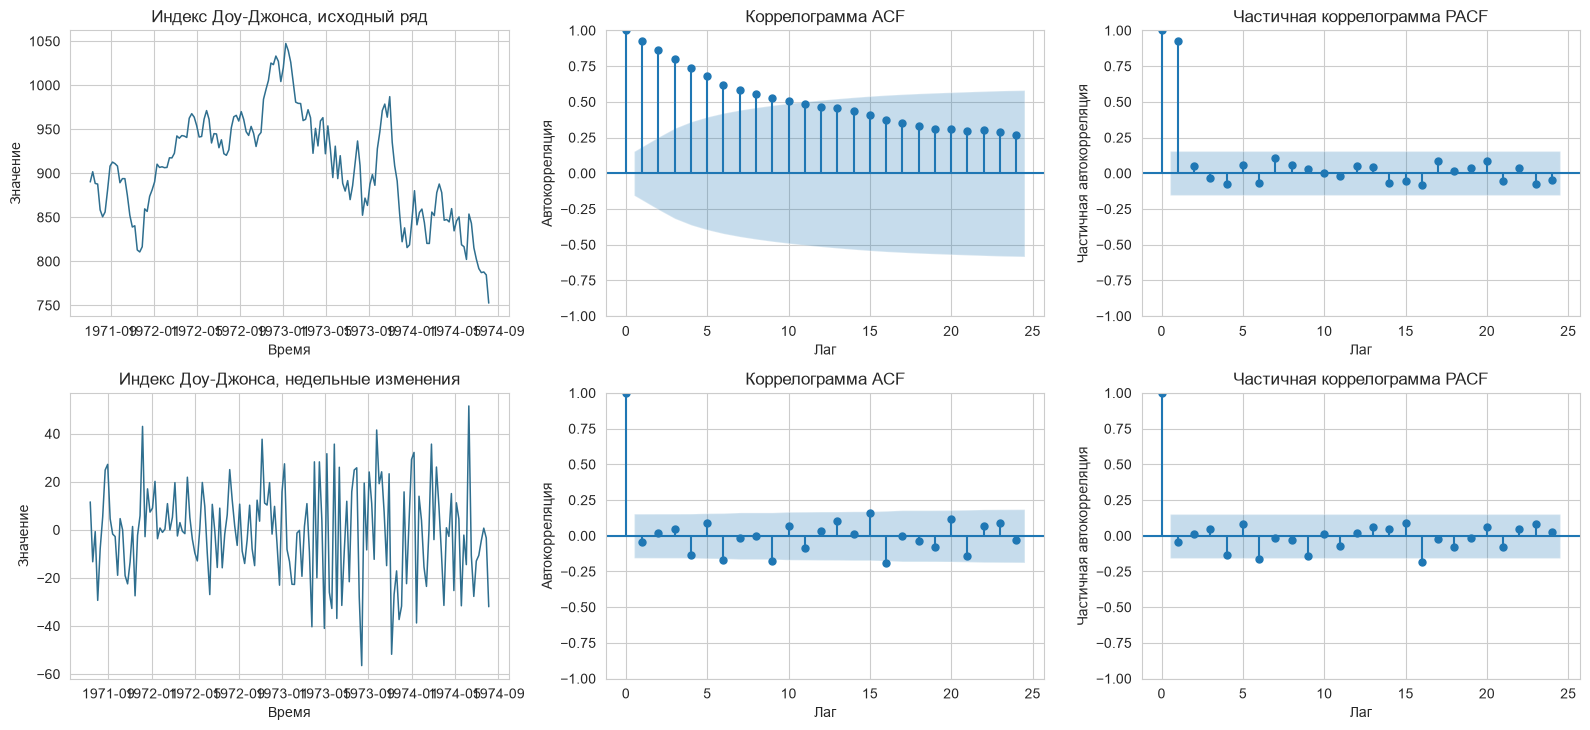

In [15]:
портрет([('Индекс Доу-Джонса, исходный ряд', ряд),
         ('Индекс Доу-Джонса, недельные изменения', доу_итог)])

**Вывод по Задаче 7:**

**Разность превращает биржевой ряд в почти некоррелированный шум.** До нее p-value **0.6225**,
ACF(1) **0.926**, все 24 лага значимы. После - p-value **0.0000**, **ACF(1) -0.042** и три
значимых лага из двадцати четырех. Это и есть определение случайного блуждания: цена следующей
недели равна цене текущей плюс новость, а сами новости между неделями не связаны.

**Логарифм здесь не нужен, и это тоже видно замером.** Разбросы исходного ряда по интервалам
37.1, 36.2, 40.1, 36.0 при среднем от 840 до 970 - они не идут за уровнем. У логарифмированного
варианта и p-value, и ACF совпадают с обычным до третьего знака.

**Но по дисперсии ряд стационарным не стал.** Разбросы недельных изменений по интервалам
14.6, 14.3, 25.3, 22.7; по половинам 14.34 против 23.89, критерий Левене дает p-value
**1.76e-06**. Логарифмирование не спасает: 0.0157 против 0.0269, p-value **6.23e-07**. Причина
не в уровне цены, а в периоде: спокойный рынок 1971-1972 годов и падение 1973-1974-го.

Слабая стационарность требует не только постоянного среднего, но и того, чтобы ковариации
зависели только от расстояния между точками. Здесь второе условие нарушено: **по среднему ряд
стационарен, по дисперсии нет**. Спокойные недели идут подряд, бурные тоже - на бирже это
называют кластеризацией волатильности, и снимается она уже не преобразованием ряда,
а отдельной моделью для самой дисперсии

### Задача 8. Ежедневные рождения девочек в Калифорнии

365 дней 1959 года - самый длинный из шести рядов и единственный дневной. На графике он больше всего
похож на шум: ни выраженного тренда, ни заметной волны.

Именно на таком ряде тест Дики-Фуллера проверять и интересно. Ряд, который выглядит как шум, - первый
кандидат на ответ «стационарен, делать ничего не надо». Прогоним его через все четыре проверки сразу
и посмотрим, сойдутся ли они

In [16]:
ряд = ряды['Рождения девочек']

print(pd.DataFrame([проверка(ряд, 'исходный ряд', сезон=7)]).to_string(index=False))
print('\nметод интервалов:')
print(интервалы(ряд).to_string(index=False))

первая, вторая = ряд.values[:182], ряд.values[183:]
print(f'\nсреднее первой половины года {первая.mean():.2f}, второй {вторая.mean():.2f}, '
      f't-тест p-value {stats.ttest_ind(первая, вторая).pvalue:.2e}')
print('среднее по месяцам:')
print({м: round(з, 1) for м, з in ряд.groupby(ряд.index.month).mean().items()})

преобразование  точек  лаг теста  p-value  разброс  ACF(1)  ACF(7)  значимых лагов из 24 разброс по интервалам
  исходный ряд    365          0      0.0   7.3483   0.217   0.195                     8   7.41 6.66 7.57 6.43

метод интервалов:
 интервал  среднее  разброс
        1  39.7717   7.4052
        2  39.8132   6.6615
        3  44.5934   7.5748
        4  43.7692   6.4275

среднее первой половины года 39.76, второй 44.18, t-тест p-value 4.85e-09
среднее по месяцам:
{1: 39.1, 2: 41.0, 3: 39.3, 4: 39.8, 5: 39.0, 6: 40.4, 7: 41.9, 8: 43.6, 9: 48.2, 10: 44.1, 11: 45.0, 12: 42.4}


In [17]:
# рост внутри года снимаем прямой: на одном годе годовую волну от тренда не отличить
t = np.arange(len(ряд))
рег = stats.linregress(t, ряд.values)
без_тренда = ряд - (рег.intercept + рег.slope * t)
print(f'наклон прямой {рег.slope:.4f} рождения в день, то есть {рег.slope * 365:.1f} за год, '
      f'p-value {рег.pvalue:.2e}')

# после снятия тренда в коррелограмме остаются лаги 7 и 21 - проверяем день недели
дни = ['понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье']
по_дням = без_тренда.groupby(без_тренда.index.dayofweek).mean()
print('отклонение от тренда по дням недели:')
print({дни[д]: round(з, 2) for д, з in по_дням.items()})
анализ = stats.f_oneway(*[г.values for _, г in без_тренда.groupby(без_тренда.index.dayofweek)])
print(f'дисперсионный анализ по дням недели: p-value {анализ.pvalue:.4f}')

профиль_дня = без_тренда.groupby(без_тренда.index.dayofweek).transform('mean')
рождения_итог = без_тренда - профиль_дня

кандидаты = pd.DataFrame([
    проверка(ряд, 'исходный ряд', сезон=7),
    проверка(ряд.diff(), 'разность', сезон=7),
    проверка(без_тренда, 'вычитание тренда', сезон=7),
    проверка(рождения_итог, 'вычитание тренда и профиля дня недели', сезон=7),
])
print('\n' + кандидаты.to_string(index=False))

наклон прямой 0.0191 рождения в день, то есть 7.0 за год, p-value 1.04e-07
отклонение от тренда по дням недели:
{'понедельник': -0.86, 'вторник': 1.74, 'среда': 1.82, 'четверг': 1.09, 'пятница': 0.03, 'суббота': -0.76, 'воскресенье': -3.09}
дисперсионный анализ по дням недели: p-value 0.0035

                       преобразование  точек  лаг теста  p-value  разброс  ACF(1)  ACF(7)  значимых лагов из 24 разброс по интервалам
                         исходный ряд    365          0      0.0   7.3483   0.217   0.195                     8   7.41 6.66 7.57 6.43
                             разность    364          5      0.0   9.1898  -0.463   0.102                     2   10.1 9.21 9.78 7.68
                     вычитание тренда    365          0      0.0   7.0670   0.156   0.140                     3    7.39 6.62 7.42 6.5
вычитание тренда и профиля дня недели    365          0      0.0   6.8786   0.138   0.095                     3   7.09 6.44 7.05 6.61


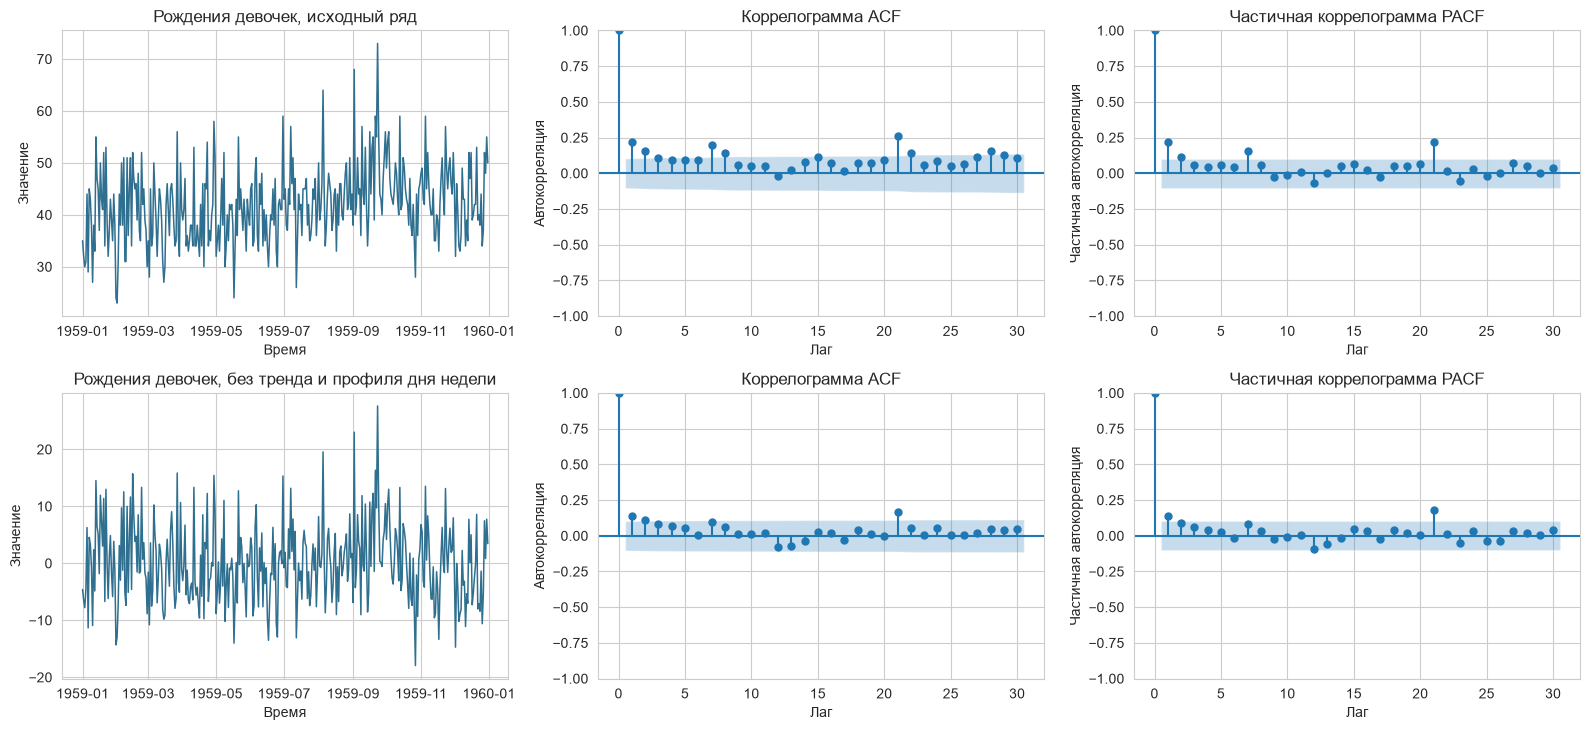

 интервал  среднее  разброс
        1   0.3870   7.0938
        2  -1.3058   6.4401
        3   1.7377   7.0493
        4  -0.8232   6.6104


In [18]:
портрет([('Рождения девочек, исходный ряд', ряд),
         ('Рождения девочек, без тренда и профиля дня недели', рождения_итог)], лагов=30)
print(интервалы(рождения_итог).to_string(index=False))

**Вывод по Задаче 8:**

**Тест сказал «стационарен», и он ошибся.** p-value меньше 0.0001, коррелограмма падает после
первого-второго лага - по этим двум признакам работа была бы закончена. Но метод интервалов
показывает средние **39.77, 39.81, 44.59, 43.77**, а t-тест по половинам года дает p-value
**4.85e-09**: во второй половине 1959 года рождений в день заметно больше.

Это не сбой теста, а граница того, что он проверяет. Дики-Фуллер ищет единичный корень,
то есть накопительный тренд. Медленная волна вокруг постоянного уровня единичного корня
не создает, и тест ее не видит.

По месяцам волна выглядит так: минимум **39.0 в мае**, максимум **48.2 в сентябре**, к декабрю
спад до 42.4. Похоже на годовую сезонность рождений, но проверить это на имеющихся данных
нельзя: **в ряду ровно один период**. Отличить годовую волну от медленного тренда можно только
на нескольких годах подряд, и до тех пор оба объяснения равноправны. Здесь подъем снимается
прямой - **0.019 рождения в день, или 7.0 за год** (p-value 1.0e-07), - как самое простое
описание, не требующее выбора между этими двумя версиями.

**После снятия прямой в коррелограмме остались лаги 7 и 21, и это день недели.** Отклонения
от тренда: воскресенье **-3.09**, среда **+1.82**, дисперсионный анализ по дням дает p-value
**0.0035**. Почему в выходные рождений меньше, из этих данных не следует; проверяемая версия -
организация работы роддомов, и для проверки нужны данные о способе родоразрешения, которых
в файле нет.

**Разность здесь была бы ошибкой.** Она поднимает разброс с 7.35 до **9.19** и загоняет ACF(1)
в **-0.463**. Вычитание тренда и профиля дня недели, наоборот, разброс уменьшает (**6.88**),
сокращает число значимых лагов с восьми до трех и оставляет ACF(1) равным 0.138

### Задача 9. Что получилось на всех шести рядах

Собираем результаты в одну таблицу: чем ряд был до преобразования и чем стал после. Рядом с p-value
теста стоят те же признаки, по которым проверка велась глазами, - автокорреляция первого лага
и отношение наибольшего разброса по интервалу к наименьшему

In [19]:
итоги = {
    'Продажи компании X': ('логарифм - тренд - профиль месяца', продажи_итог),
    'Ограбления в Бостоне': ('логарифм + разность', ограбления_итог),
    'Пассажиры авиалиний': ('логарифм + сезонная разность + разность', авиа_итог),
    'Температура воздуха': ('вычитание профиля месяца', температура_итог),
    'Индекс Доу-Джонса': ('разность', доу_итог),
    'Рождения девочек': ('вычитание тренда и профиля дня недели', рождения_итог),
}

# два взгляда на разброс: наибольший кусок к наименьшему говорит о постоянстве,
# последний к первому - о том, растет разброс со временем или нет
макс_мин = lambda куски: max(к.std(ddof=1) for к in куски) / min(к.std(ddof=1) for к in куски)
последний_первый = lambda куски: куски[-1].std(ddof=1) / куски[0].std(ddof=1)

сводка = []
for имя, (что_сделали, итог) in итоги.items():
    было, стало = ряды[имя].dropna(), итог.dropna()
    к_было, к_стало = np.array_split(было.values, 4), np.array_split(стало.values, 4)
    сводка.append({'ряд': имя, 'преобразование': что_сделали,
                   'p до': round(adfuller(было, autolag='BIC')[1], 4),
                   'p после': round(adfuller(стало, autolag='BIC')[1], 4),
                   'ACF(1) до': round(acf(было, nlags=1)[1], 3),
                   'ACF(1) после': round(acf(стало, nlags=1)[1], 3),
                   'макс/мин до': round(макс_мин(к_было), 2),
                   'макс/мин после': round(макс_мин(к_стало), 2),
                   'последний/первый до': round(последний_первый(к_было), 2),
                   'последний/первый после': round(последний_первый(к_стало), 2)})

print(pd.DataFrame(сводка).to_string(index=False))

                 ряд                          преобразование   p до  p после  ACF(1) до  ACF(1) после  макс/мин до  макс/мин после  последний/первый до  последний/первый после
  Продажи компании X       логарифм - тренд - профиль месяца 0.9889   0.0026      0.871         0.561         2.88            1.14                 2.88                    0.97
Ограбления в Бостоне                     логарифм + разность 0.7499   0.0000      0.928        -0.229         4.13            1.56                 4.13                    0.64
 Пассажиры авиалиний логарифм + сезонная разность + разность 0.9919   0.0000      0.948        -0.341         3.18            2.82                 3.18                    0.69
 Температура воздуха                вычитание профиля месяца 0.0594   0.0000      0.808         0.237         1.13            1.30                 1.07                    0.77
   Индекс Доу-Джонса                                разность 0.6225   0.0000      0.926        -0.042         1.11      

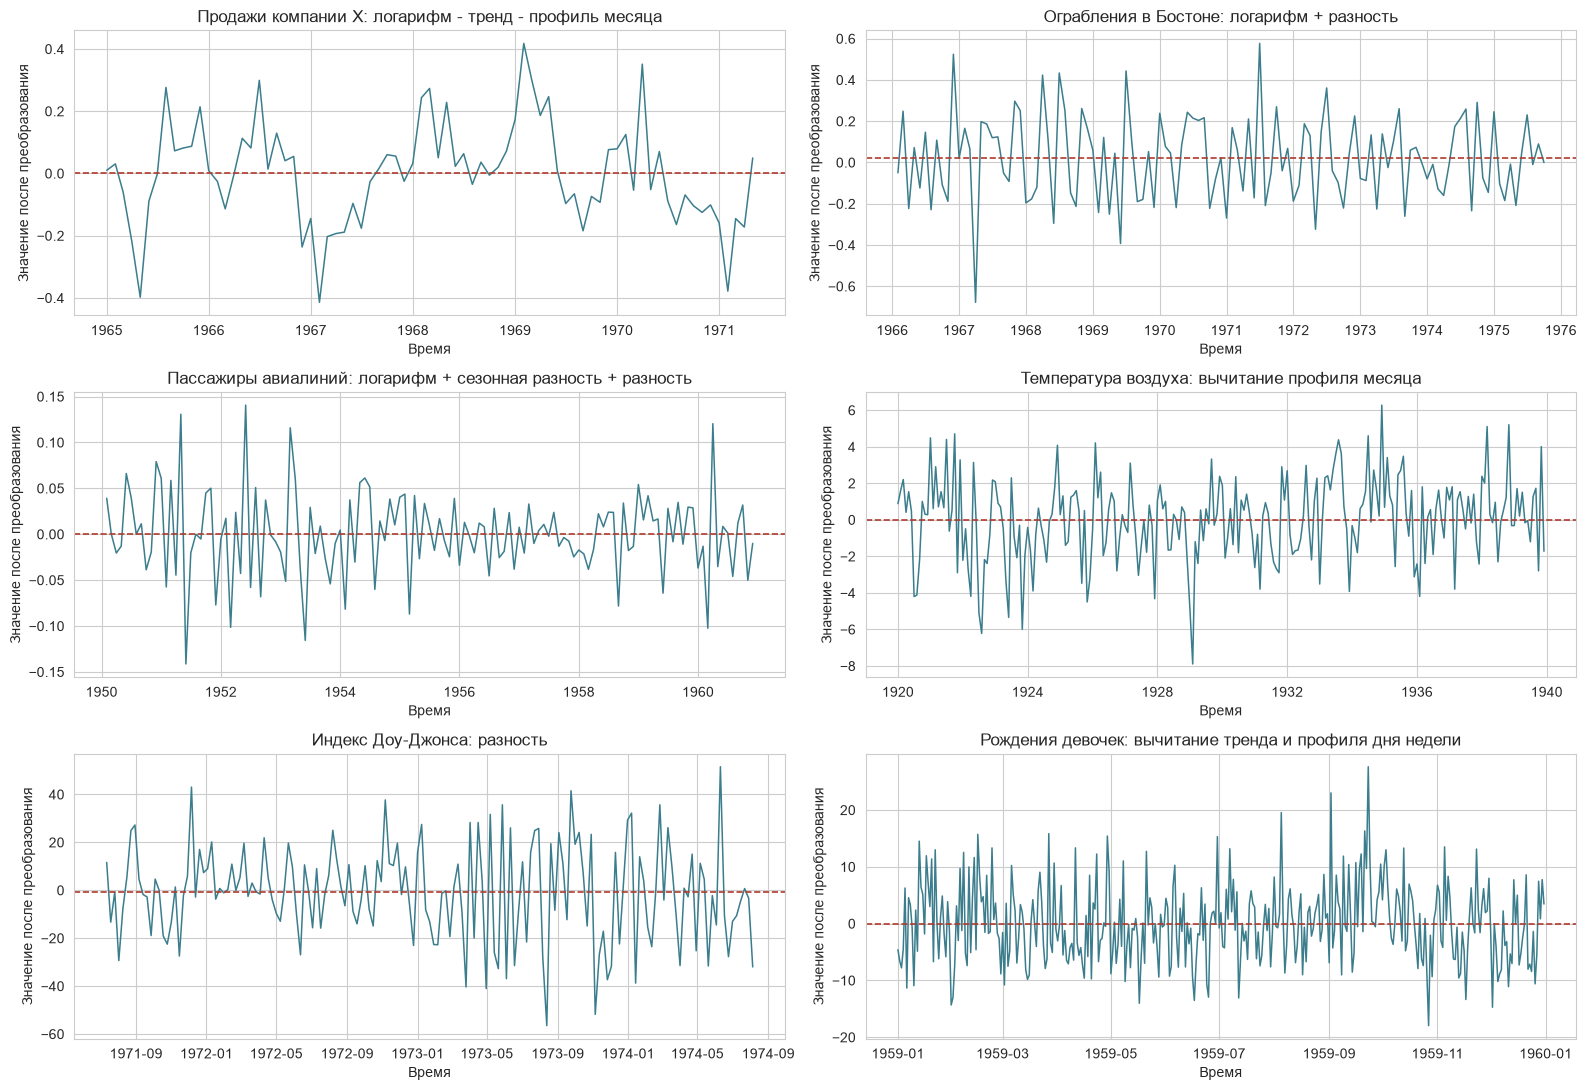

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(16, 11))
for ось, (имя, (что_сделали, итог)) in zip(axes.flatten(), итоги.items()):
    ось.plot(итог.index, итог.values, color='#3b7d8c', linewidth=1.1)
    ось.axhline(итог.mean(), color='#b03a2e', linewidth=1.2, linestyle='--')
    ось.set_title(f'{имя}: {что_сделали}')
    ось.set_xlabel('Время')
    ось.set_ylabel('Значение после преобразования')
plt.tight_layout()
plt.show()

**Вывод по Задаче 9:**

**Шесть рядов потребовали четырех разных наборов операций.** Пять из шести до преобразования тест
стационарными не признал (p-value от 0.0594 до 0.9919), шестой признал ошибочно.
После преобразования p-value у всех шести не превышает **0.0026**.

*   **Логарифм понадобился трем рядам** - продажам, ограблениям и пассажирам. Признак один и тот же:
    разброс идет за уровнем, отношение разброса последнего интервала к первому **2.9-4.1**.
    Трем остальным логарифм не нужен, у них это отношение 0.87-1.07 еще до всякой обработки.
*   **Разность против вычитания компоненты - это про природу тренда и сезонности.** Там, где уровень
    сдвигается и остается на новом месте (ограбления, пассажиры, Доу-Джонс), работает разность.
    Там, где компонента воспроизводится из года в год или описывается одной линией (продажи,
    температура, рождения), работает вычитание оцененной компоненты, а разность портит результат.
*   **Автокорреляция после преобразования не исчезает и не должна.** ACF(1) итоговых рядов лежит
    от **-0.341** у пассажиров до **+0.561** у продаж. Стационарность означает постоянство
    статистических свойств во времени, а не независимость соседних точек; именно оставшаяся
    зависимость и есть то, что моделируют дальше.
*   **Один результат неполон.** У Доу-Джонса отношение разброса последнего интервала к первому
    после преобразования **1.56** - выше, чем было до него. Разность сняла тренд, но неоднородность
    дисперсии осталась, и это видно в таблице так же ясно, как удача на остальных пяти рядах

### Дополнительный эксперимент 1 (вне рамок задания). Встречная проверка тестом KPSS

Тест Дики-Фуллера проверяет нестационарность против стационарности, и «стационарен» - это у него
вывод по отвергнутой гипотезе. Когда p-value велико, это значит только, что данных не хватило,
а не что ряд точно нестационарен.

Тест KPSS устроен зеркально: у него в нулевой гипотезе стоит стационарность, и большое p-value
означает «оснований спорить нет». Прогоним оба теста по всем шести рядам, до и после преобразования.
Интересны случаи, где они расходятся

In [21]:
встречно = []
for имя, (что_сделали, итог) in итоги.items():
    for подпись, x in [('до', ряды[имя].dropna()), ('после', итог.dropna())]:
        p_adf = adfuller(x, autolag='BIC')[1]
        # KPSS предупреждает каждый раз, когда упирается в границу таблицы, а упирается он тут почти
        # всегда: гасим предупреждение по месту, чтобы оно не заслоняло саму таблицу
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            p_kpss = kpss(x, regression='c', nlags='auto')[1]
        встречно.append({'ряд': имя, 'состояние': подпись,
                         'ADF p-value': round(p_adf, 4),
                         'ADF вердикт': 'стационарен' if p_adf < 0.05 else 'нет',
                         'KPSS p-value': round(p_kpss, 4),
                         'KPSS вердикт': 'стационарен' if p_kpss > 0.05 else 'нет'})

print(pd.DataFrame(встречно).to_string(index=False))
print('\np-value у KPSS в statsmodels обрезано снизу 0.01 и сверху 0.1: за пределами коридора '
      'тест возвращает границу, а не точное число')

                 ряд состояние  ADF p-value ADF вердикт  KPSS p-value KPSS вердикт
  Продажи компании X        до       0.9889         нет        0.0100          нет
  Продажи компании X     после       0.0026 стационарен        0.1000  стационарен
Ограбления в Бостоне        до       0.7499         нет        0.0100          нет
Ограбления в Бостоне     после       0.0000 стационарен        0.1000  стационарен
 Пассажиры авиалиний        до       0.9919         нет        0.0100          нет
 Пассажиры авиалиний     после       0.0000 стационарен        0.1000  стационарен
 Температура воздуха        до       0.0594         нет        0.1000  стационарен
 Температура воздуха     после       0.0000 стационарен        0.0568  стационарен
   Индекс Доу-Джонса        до       0.6225         нет        0.0241          нет
   Индекс Доу-Джонса     после       0.0000 стационарен        0.1000  стационарен
    Рождения девочек        до       0.0000 стационарен        0.0100          нет
    

**Вывод по дополнительному эксперименту 1:**

**По итоговым рядам тесты согласны полностью:** во всех шести случаях ADF отвергает
нестационарность, а KPSS не находит оснований спорить со стационарностью (p-value 0.1 - это
потолок таблицы). Единственное значение не на потолке - температура после вычитания профиля,
**0.0568**, у самой границы.

**Расхождения нашлись до преобразования, причем в обе стороны.**

*   **Температура:** ADF 0.0594 («нет»), KPSS 0.1 («стационарен»). Годовую волну, которая видна
    на графике невооруженным глазом, KPSS пропустил целиком.
*   **Рождения:** ADF 0.0000 («стационарен»), KPSS 0.01 («нет»). Здесь наоборот - KPSS поймал
    тот самый медленный сдвиг уровня, который ADF не увидел.

Почему KPSS пропустил годовую волну, из таблицы не следует. Проверяемая версия: статистика KPSS
строится на накопленных суммах отклонений от среднего, а быстрая волна в накопленной сумме гасит
сама себя, тогда как медленный сдвиг уровня в ней накапливается. Проверить можно на искусственных
рядах: чистая синусоида с периодом 12 плюс шум против того же шума с медленным сдвигом среднего.

Практический вывод: **два теста дополняют друг друга, но не заменяют коррелограмму**. Оба ряда,
на которых они разошлись, определяются по ACF за одну секунду - у температуры ACF(12) равен 0.884

### Дополнительный эксперимент 2 (вне рамок задания). Цена лишнего дифференцирования

В нескольких задачах выбор между вариантами делался по одному и тому же признаку: лишняя разность
раздувает разброс и загоняет автокорреляцию первого лага в минус. Проверим это правило разом
на всех шести готовых рядах: каждый из них уже стационарен, и каждому добавим еще одну разность.

Если правило верно, картина должна быть одинаковой независимо от того, чем ряд приводили
к стационарности

In [22]:
лишняя = []
for имя, (что_сделали, итог) in итоги.items():
    было = итог.dropna()
    стало = было.diff().dropna()
    # разброс разности связан с автокорреляцией исходного ряда:
    # дисперсия разности равна 2 * дисперсия * (1 - ACF(1)), отсюда предсказание для отношения
    предсказание = np.sqrt(2 * (1 - acf(было, nlags=1)[1]))
    лишняя.append({'ряд': имя,
                   'разброс до': round(было.std(), 4),
                   'разброс после': round(стало.std(), 4),
                   'во сколько раз': round(стало.std() / было.std(), 2),
                   'по формуле': round(предсказание, 2),
                   'ACF(1) до': round(acf(было, nlags=1)[1], 3),
                   'ACF(1) после': round(acf(стало, nlags=1)[1], 3)})

print(pd.DataFrame(лишняя).to_string(index=False))

                 ряд  разброс до  разброс после  во сколько раз  по формуле  ACF(1) до  ACF(1) после
  Продажи компании X      0.1635         0.1542            0.94        0.94      0.561        -0.411
Ограбления в Бостоне      0.2071         0.3260            1.57        1.57     -0.229        -0.525
 Пассажиры авиалиний      0.0458         0.0753            1.64        1.64     -0.341        -0.666
 Температура воздуха      2.2593         2.7945            1.24        1.24      0.237        -0.444
   Индекс Доу-Джонса     19.8531        28.6188            1.44        1.44     -0.042        -0.523
    Рождения девочек      6.8786         9.0393            1.31        1.31      0.138        -0.485


**Вывод по дополнительному эксперименту 2:**

**Признак передифференцирования сработал на всех шести рядах:** ACF(1) после лишней разности
отрицателен везде, от **-0.411** до **-0.666**, независимо от того, чем ряд приводили
к стационарности - логарифмом, разностью или вычитанием компоненты.

**А вот разброс растет не всегда, и таблица объясняет, когда именно.** У пяти рядов он вырос
в 1.24-1.64 раза, у продаж компании X **уменьшился** - в 0.94 раза. Дисперсия разности равна
удвоенной дисперсии ряда, умноженной на (1 - ACF(1)), поэтому предсказанное отношение разбросов
это корень из 2 * (1 - ACF(1)). Столбец «по формуле» совпал с замеренным **у всех шести рядов
до второго знака**: 0.94 при ACF(1) 0.561 у продаж, 1.64 при -0.341 у пассажиров.

Отсюда точная формулировка правила, которым делался выбор в задачах 3, 6 и 8: **разность раздувает
разброс, только если автокорреляция первого лага меньше 0.5**. При ACF(1) выше 0.5 разность разброс
уменьшает, и один этот признак ничего не докажет - смотреть надо на знак ACF(1) после нее